In [1]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rm1000/grape-disease-dataset-original")

print("Path to dataset files:", path)

Path to dataset files: /home/ubuntu/.cache/kagglehub/datasets/rm1000/grape-disease-dataset-original/versions/1


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pushpalama/grape-disease")

print("Path to dataset files:", path)

100%|██████████| 151M/151M [00:06<00:00, 25.2MB/s] 

Extracting files...


Path to dataset files: /home/ubuntu/.cache/kagglehub/datasets/pushpalama/grape-disease/versions/1


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.04G/2.04G [01:15<00:00, 28.9MB/s]

Extracting files...


Path to dataset files: /home/ubuntu/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jawadulkarim117/grape-leaf-disease-4-class")

print("Path to dataset files:", path)

Path to dataset files: /home/ubuntu/.cache/kagglehub/datasets/jawadulkarim117/grape-leaf-disease-4-class/versions/1


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bmshahriaalam/grape-leaf-disease")

print("Path to dataset files:", path)

Path to dataset files: /home/ubuntu/.cache/kagglehub/datasets/bmshahriaalam/grape-leaf-disease/versions/1


In [6]:
!pip install pillow opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 37.1 MB/s  0:00:01m0:00:0100:01


In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Set base directory
base_dir = '/home/ubuntu/GddAi/dd_cnn/dataset'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

In [8]:
# Explore dataset structure
print("Dataset Structure:")
print(f"Base directory: {base_dir}")
print(f"\nTrain directory: {train_dir}")
print(f"Test directory: {test_dir}")

# List classes in train and test
train_classes = sorted(os.listdir(train_dir)) if os.path.exists(train_dir) else []
test_classes = sorted(os.listdir(test_dir)) if os.path.exists(test_dir) else []

print(f"\n{'='*50}")
print(f"Number of classes in train: {len(train_classes)}")
print(f"Classes: {train_classes}")

print(f"\n{'='*50}")
print(f"Number of classes in test: {len(test_classes)}")
print(f"Classes: {test_classes}")

# Count images per class
print(f"\n{'='*50}")
print("Images per class in train:")
for cls in train_classes:
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls}: {num_images} images")

print(f"\n{'='*50}")
print("Images per class in test:")
for cls in test_classes:
    cls_path = os.path.join(test_dir, cls)
    if os.path.isdir(cls_path):
        num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls}: {num_images} images")

Dataset Structure:
Base directory: /home/ubuntu/GddAi/dd_cnn/dataset

Train directory: /home/ubuntu/GddAi/dd_cnn/dataset/train
Test directory: /home/ubuntu/GddAi/dd_cnn/dataset/test

Number of classes in train: 6
Classes: ['Black Measles', 'Black Rot', 'ESCA', 'Healthy', 'Isariopsis Leaf Spot', 'Leaf Blight']

Number of classes in test: 6
Classes: ['Black Measles', 'Black Rot', 'ESCA', 'Healthy', 'Isariopsis Leaf Spot', 'Leaf Blight']

Images per class in train:
  Black Measles: 2161 images
  Black Rot: 8313 images
  ESCA: 7920 images
  Healthy: 8058 images
  Isariopsis Leaf Spot: 1933 images
  Leaf Blight: 7722 images

Images per class in test:
  Black Measles: 239 images
  Black Rot: 653 images
  ESCA: 480 images
  Healthy: 600 images
  Isariopsis Leaf Spot: 219 images
  Leaf Blight: 430 images


Sample images from training set:


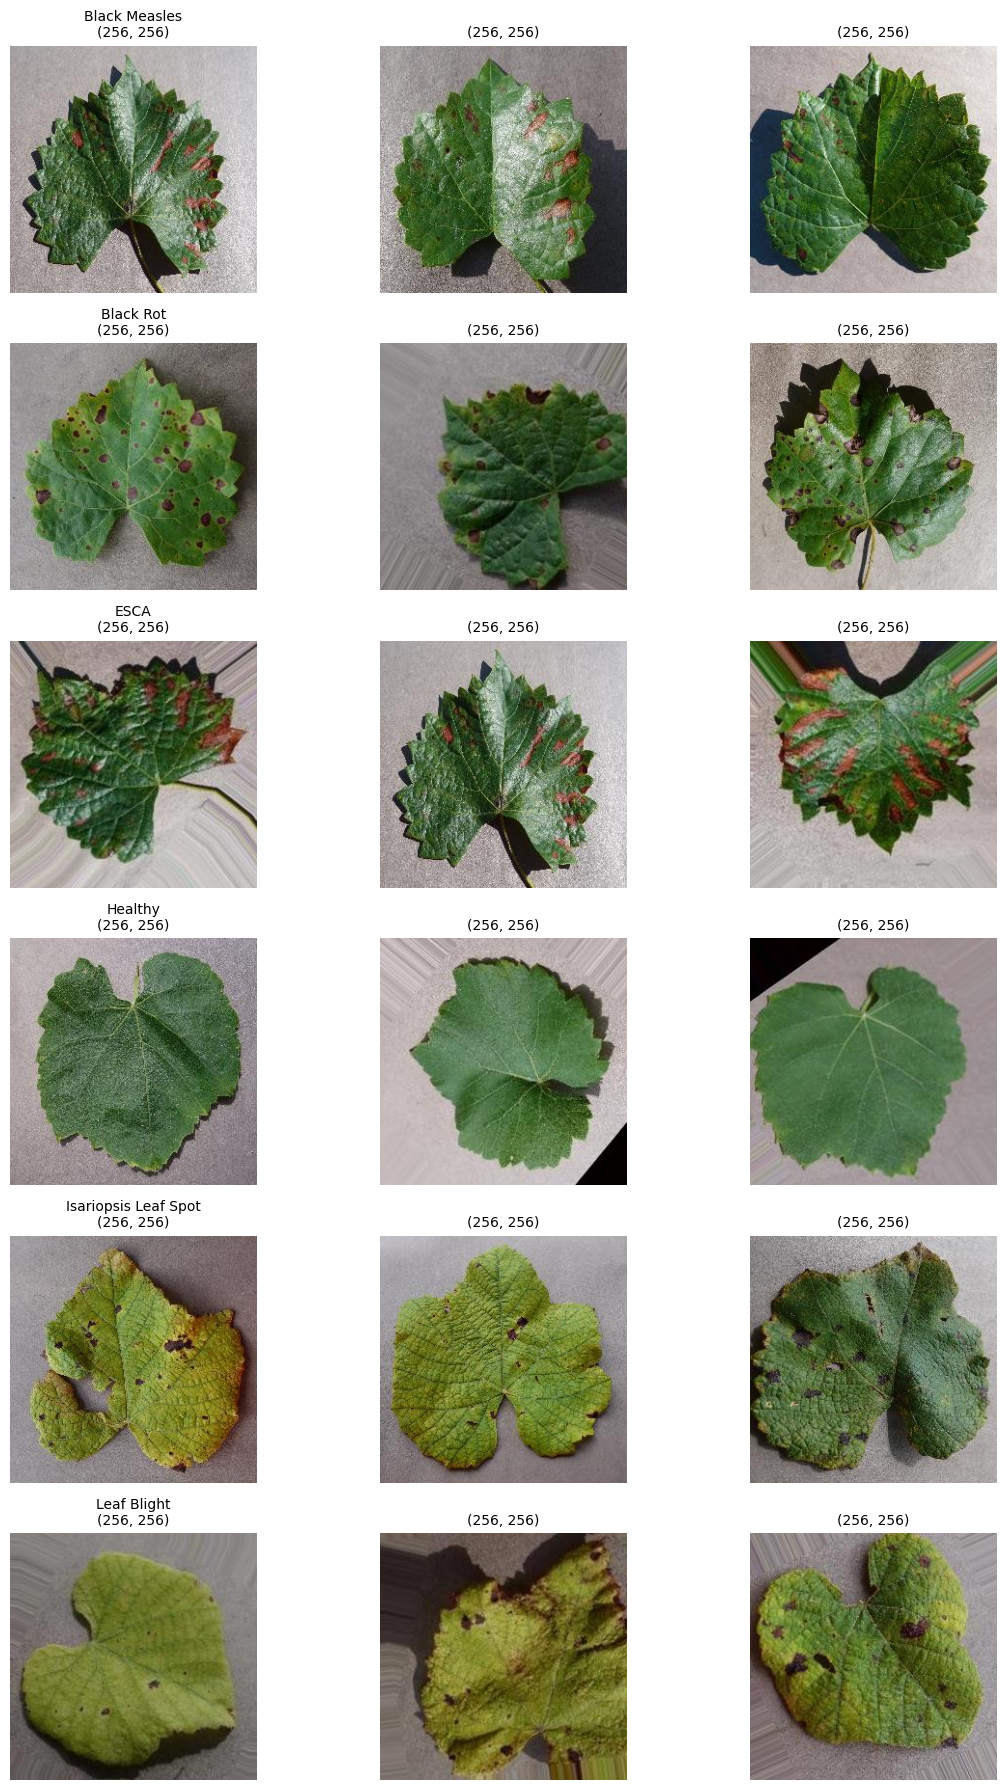

In [9]:
# Visualize sample images from each class
def show_sample_images(data_dir, num_samples=3):
    classes = sorted(os.listdir(data_dir))
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(12, 3*len(classes)))
    
    if len(classes) == 1:
        axes = axes.reshape(1, -1)
    
    for i, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:num_samples]
            
            for j, img_name in enumerate(images):
                img_path = os.path.join(cls_path, img_name)
                img = Image.open(img_path)
                
                if len(classes) == 1:
                    ax = axes[j]
                else:
                    ax = axes[i, j]
                
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    ax.set_title(f"{cls}\n{img.size}", fontsize=10)
                else:
                    ax.set_title(f"{img.size}", fontsize=10)
    
    plt.tight_layout()
    plt.show()

print("Sample images from training set:")
show_sample_images(train_dir)

In [10]:
# Analyze image dimensions
def analyze_image_dimensions(data_dir):
    widths = []
    heights = []
    
    classes = sorted(os.listdir(data_dir))
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for img_name in images:
                img_path = os.path.join(cls_path, img_name)
                img = Image.open(img_path)
                widths.append(img.width)
                heights.append(img.height)
    
    print(f"Image dimensions analysis:")
    print(f"  Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.1f}")
    print(f"  Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}")
    
    return widths, heights

print("Training set:")
train_widths, train_heights = analyze_image_dimensions(train_dir)

print(f"\nTest set:")
test_widths, test_heights = analyze_image_dimensions(test_dir)

Training set:
Image dimensions analysis:
  Width  - Min: 256, Max: 256, Mean: 256.0
  Height - Min: 256, Max: 256, Mean: 256.0

Test set:
Image dimensions analysis:
  Width  - Min: 256, Max: 256, Mean: 256.0
  Height - Min: 256, Max: 256, Mean: 256.0


In [13]:
#check duplicate images in the dataset.
import os
from collections import defaultdict
import hashlib  
def find_duplicate_images(data_dir):
    hash_dict = defaultdict(list)
    
    classes = sorted(os.listdir(data_dir))
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for img_name in images:
                img_path = os.path.join(cls_path, img_name)
                with open(img_path, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()
                    hash_dict[file_hash].append(img_path)
    
    duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}
    
    return duplicates

print("the duplicates number in training set:"+str(len(find_duplicate_images(train_dir))))
print("the duplicates number in test set:"+str(len(find_duplicate_images(test_dir))))

the duplicates number in training set:4124
the duplicates number in test set:95


In [14]:
# print total number of images clasese in the dataset
def count_total_images(data_dir):
    total_images = 0
    
    classes = sorted(os.listdir(data_dir))
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            total_images += len(images)
    
    return total_images
total_train_images = count_total_images(train_dir)
total_test_images = count_total_images(test_dir)
print("Total training images:", total_train_images)
print("Total test images:", total_test_images)

Total training images: 36107
Total test images: 2621


In [15]:
# I want to print the available image classes in the dataset
print("Available image classes in training set:", train_classes)
print("Available image classes in test set:", test_classes)

Available image classes in training set: ['Black Measles', 'Black Rot', 'ESCA', 'Healthy', 'Isariopsis Leaf Spot', 'Leaf Blight']
Available image classes in test set: ['Black Measles', 'Black Rot', 'ESCA', 'Healthy', 'Isariopsis Leaf Spot', 'Leaf Blight']


In [ ]:
in the dataset the classes 

In [16]:
print("Number of training classes:", len(train_classes))
print("Number of test classes:", len(test_classes))


Number of training classes: 6
Number of test classes: 6


In [17]:
#print number of images per each class in the dataset
print(f"\n{'='*50}")
print("Images per class in train:")
for cls in train_classes:
    cls_path = os.path.join(train_dir, cls)
    if os.path.isdir(cls_path):
        num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls}: {num_images} images")          

print(f"\n{'='*50}")
print("Images per class in test:")
for cls in test_classes:
    cls_path = os.path.join(test_dir, cls)
    if os.path.isdir(cls_path):
        num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {cls}: {num_images} images")          

print(f"\n{'='*50}")
print("Total training images:", total_train_images)
print("Total test images:", total_test_images)



Images per class in train:
  Black Measles: 2161 images
  Black Rot: 8313 images
  ESCA: 7920 images
  Healthy: 8058 images
  Isariopsis Leaf Spot: 1933 images
  Leaf Blight: 7722 images

Images per class in test:
  Black Measles: 239 images
  Black Rot: 653 images
  ESCA: 480 images
  Healthy: 600 images
  Isariopsis Leaf Spot: 219 images
  Leaf Blight: 430 images

Total training images: 36107
Total test images: 2621
